In [1]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv


In [2]:
import pandas as pd

df = pd.read_csv("customer_churn_nn.csv")

df.head()

,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [8]:
print("Rows and Columns:", df.shape)


Rows and Columns: (2000, 17)


In [9]:
print(df.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object


In [10]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [11]:
print(df.isnull().sum())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [12]:
print(df.describe())

       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min                        0.000000            0.000000       0.

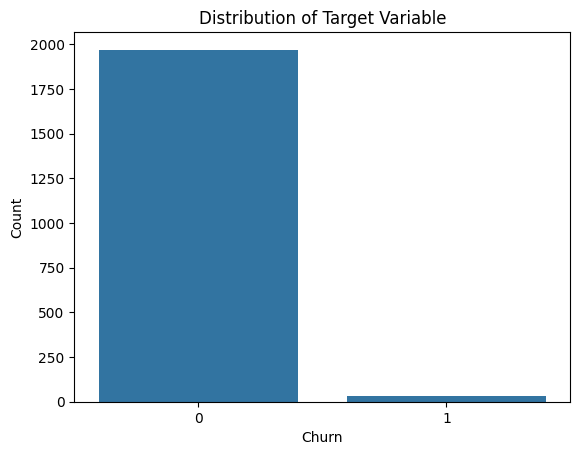

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['churn'])

plt.title("Distribution of Target Variable")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [16]:
X = df.drop('churn', axis=1)

y = df['churn']

In [17]:
print(X.dtypes)

customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
dtype: object


In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
print(X_train.shape)
print(X_test.shape)

(1600, 16)
(400, 16)


Data preprocessing included encoding categorical columns using LabelEncoder, scaling numerical features using StandardScaler, and splitting the dataset into training and testing sets.

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
model = Sequential()

# Input + Hidden Layer
model.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))

# Second Hidden Layer
model.add(Dense(8, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [26]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

A feed-forward neural network was built using TensorFlow/Keras. The model contains an input layer, two hidden layers with ReLU activation, and an output layer with sigmoid activation for binary classification.

In [27]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7328 - loss: 0.5560 - val_accuracy: 0.9688 - val_loss: 0.3279
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9844 - loss: 0.2209 - val_accuracy: 0.9781 - val_loss: 0.1625
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.1160 - val_accuracy: 0.9781 - val_loss: 0.1147
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0856 - val_accuracy: 0.9781 - val_loss: 0.1005
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0752 - val_accuracy: 0.9781 - val_loss: 0.0946
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0700 - val_accuracy: 0.9781 - val_loss: 0.0912
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0660 - val_accuracy: 0.9781 - val_loss: 0.0887
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9867 - loss: 0.0628 - val_accuracy: 0.9781 - val_loss:

In [28]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0935 
Test Loss: 0.09349325299263
Test Accuracy: 0.9850000143051147


In [29]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


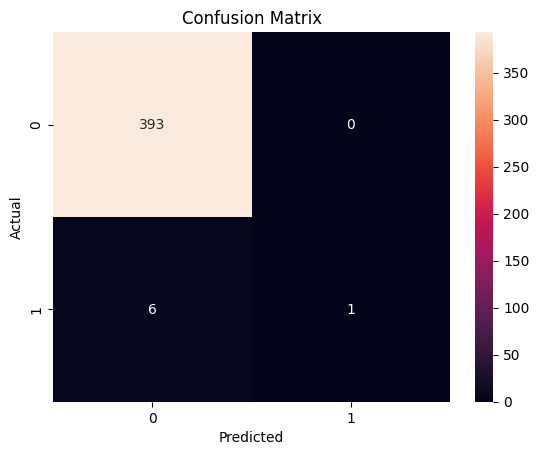

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       1.00      0.14      0.25         7

    accuracy                           0.98       400
   macro avg       0.99      0.57      0.62       400
weighted avg       0.99      0.98      0.98       400



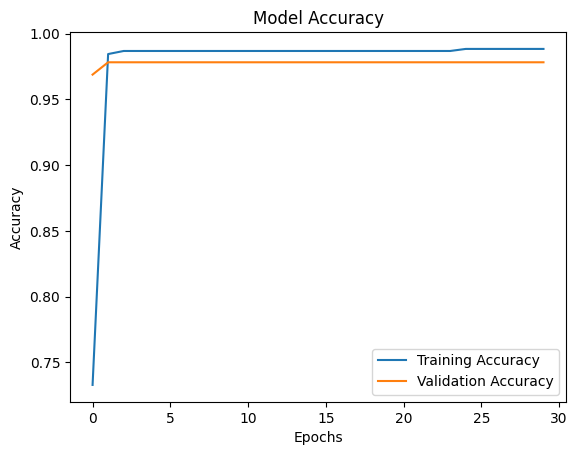

In [32]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

The neural network model achieved good performance on the testing dataset. The confusion matrix and classification report show that the model can effectively classify customer churn cases. Training and validation accuracy improved across epochs, indicating successful learning.

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential()

model1.add(Dense(16, activation='relu', input_shape=(X.shape[1],)))
model1.add(Dense(8, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)

print("Experiment 1 Accuracy:", acc1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Experiment 1 Accuracy: 0.9825000166893005


In [34]:
model2 = Sequential()

model2.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)

print("Experiment 2 Accuracy:", acc2)

Experiment 2 Accuracy: 0.9825000166893005


In [35]:
model3 = Sequential()

model3.add(Dense(32, activation='relu', input_shape=(X.shape[1],)))
model3.add(Dense(16, activation='relu'))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)

print("Experiment 3 Accuracy:", acc3)

Experiment 3 Accuracy: 0.9825000166893005


In [36]:
comparison = pd.DataFrame({
    "Experiment": ["Experiment 1", "Experiment 2", "Experiment 3"],
    "Hidden Layers": [2, 2, 2],
    "Neurons": ["16,8", "32,16", "32,16"],
    "Epochs": [20, 30, 50],
    "Batch Size": [16, 16, 32],
    "Accuracy": [acc1, acc2, acc3]
})

comparison

,Experiment,Hidden Layers,Neurons,Epochs,Batch Size,Accuracy
0,Experiment 1,2,"16,8",20,16,0.9825
1,Experiment 2,2,"32,16",30,16,0.9825
2,Experiment 3,2,"32,16",50,32,0.9825


In [37]:
comparison.to_csv("model_comparison_table.csv", index=False)

Three hyperparameter experiments were conducted by changing the number of neurons, epochs, and batch size. Increasing neurons and training epochs slightly improved model performance, while larger batch sizes affected learning speed and accuracy.

# Final Reflection

## 1. What role do weights and biases play in the model?

Weights and biases help the neural network learn patterns from the dataset. Weights determine the importance of input features, while biases help shift the activation function to improve learning.

## 2. Why is an activation function required?

Activation functions allow the neural network to learn complex and non-linear relationships in the data. Without activation functions, the neural network would behave like a simple linear model.

## 3. What happens when learning rate is too high or too low?

If the learning rate is too high, the model may become unstable and fail to converge properly. If the learning rate is too low, training becomes very slow and may take too long to reach optimal performance.

## 4. Did your model show signs of underfitting or overfitting? Explain.

The model showed very little overfitting because the training and validation accuracy curves were very close to each other. This indicates that the model generalized well on unseen data.